In [2]:
import pandas as pd
import numpy as np
import os
import joblib
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# Load environment variables and establish a connection to the database
load_dotenv("../.env")
DATABASE_URL = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DATABASE_URL)

# Retrieve training data from the database
X_train = pd.read_sql('SELECT * FROM "X_train"', engine)
y_train = pd.read_sql('SELECT * FROM "y_train"', engine).values.ravel()

# Define numerical ranks for categorical features that have a natural order
complex_mapping = {
    'exter_qual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'exter_cond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'bsmt_qual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'bsmt_cond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'heating_qc': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'kitchen_qual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'fireplace_qu': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'garage_qual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'garage_cond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'pool_qc': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'None': 0},
    'lot_shape': {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1},
    'land_slope': {'Gtl': 3, 'Mod': 2, 'Sev': 1},
    'bsmt_exposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'garage_finish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'utilities': {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1},
    'functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
}

def ordinal_encode(df, mapping):
    #Apply ordinal encoding to categorical columns based on the provided mapping dictionary.
    df = df.copy()
    for col, m in mapping.items():
        if col in df.columns:
            df[col] = df[col].map(m).fillna(0).astype(int)
    return df

# Transform the training data using our ordinal encoding function
X_train_encoded = ordinal_encode(X_train, complex_mapping)

# Identify numerical and categorical features for separate processing
numeric_features = X_train_encoded.select_dtypes(include='number').columns.tolist()
categorical_features = X_train_encoded.select_dtypes(include=['object','string']).columns.tolist()

# Define a unified preprocessing pipeline for both feature types
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

# Initialize a dictionary of regression models for benchmarking
models = {
    'XGBoost': XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    depth=4,              
    l2_leaf_reg=20.0,     
    random_strength=2.0,
    bootstrap_type='MVS',
    random_state=42,
    verbose=0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0)
}

# Store cross-validation results to compare model performances later
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    cv_scores = cross_val_score(pipeline, X_train_encoded, y_train, cv=5, scoring='r2')
    
    pipeline.fit(X_train_encoded, y_train)
    train_score = pipeline.score(X_train_encoded, y_train)
    
    results.append({
        'Model': name,
        'Train_R2': train_score,
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std(),
        'Gap': train_score - cv_scores.mean() 
    })
    print(f"Evaluated {name}...")

results_df = pd.DataFrame(results).sort_values(by='CV_R2_Mean', ascending=False)
print(results_df)

Evaluated XGBoost...
Evaluated LightGBM...
Evaluated CatBoost...
Evaluated RandomForest...
Evaluated Ridge...
          Model  Train_R2  CV_R2_Mean  CV_R2_Std       Gap
1      LightGBM  0.998879    0.903678   0.010993  0.095201
2      CatBoost  0.931250    0.898858   0.013207  0.032392
4         Ridge  0.933045    0.896514   0.014712  0.036531
0       XGBoost  0.999278    0.890591   0.013774  0.108687
3  RandomForest  0.982925    0.878661   0.013097  0.104264


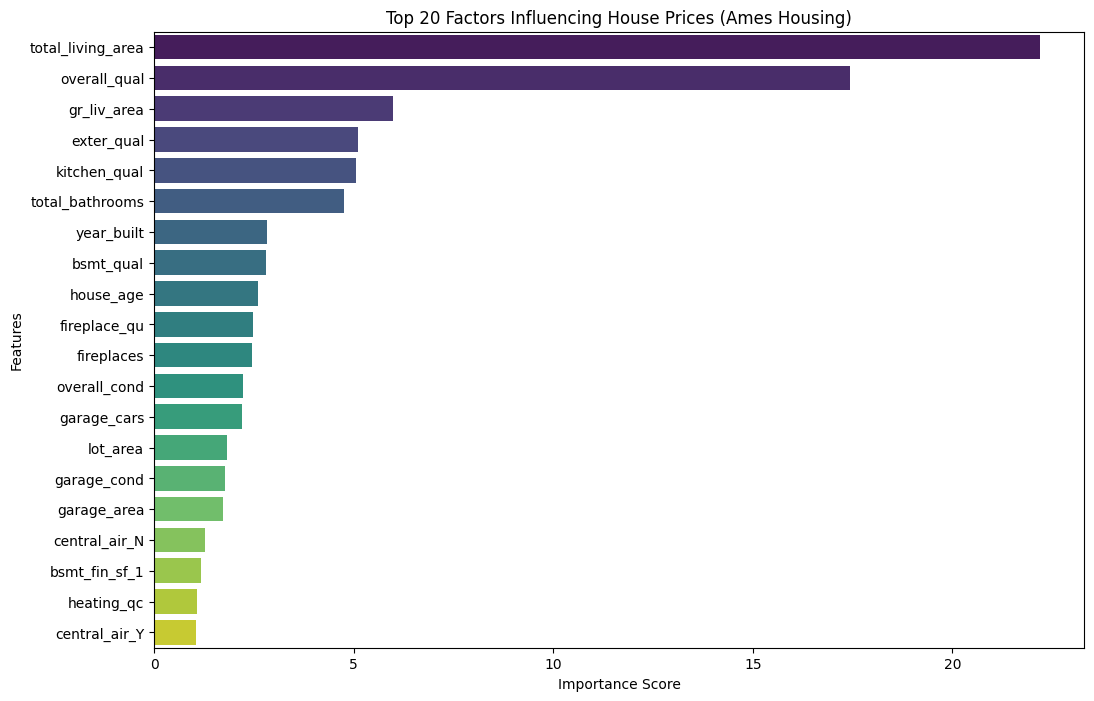

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models['CatBoost'])
])
final_pipeline.fit(X_train_encoded, y_train)

ohe_cols = final_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

importances = final_pipeline.named_steps['model'].get_feature_importance()

fi_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Top 20 Factors Influencing House Prices (Ames Housing)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [10]:
top_features = fi_df[fi_df['Importance'] > 0.5]['Feature'].tolist()
print(len(top_features))

X_train_reduced = pd.DataFrame(preprocessor.fit_transform(X_train_encoded), columns=all_feature_names)[top_features]

cv_reduced = cross_val_score(models['CatBoost'], X_train_reduced, y_train, cv=5, scoring='r2')
print(f"{cv_reduced.mean():.4f}")

20
0.8859


In [11]:
import os

model_path = "../models/"

final_model = models['CatBoost'].fit(X_train_reduced, y_train)

joblib.dump(final_model, os.path.join(model_path, 'house_price_model.joblib'))
joblib.dump(top_features, os.path.join(model_path, 'important_features.joblib'))
joblib.dump(preprocessor, os.path.join(model_path, 'preprocessor.joblib'))

['../models/preprocessor.joblib']